# Telco Customer Churn — Data Preprocessing

Cleans and prepares the Telco Customer Churn dataset (`data.csv`) for model training:
missing-value handling, dtype fixes, exploratory visuals (class balance, distribution
shape, correlations), categorical encoding, feature scaling, and a stratified
70/15/15 train/validation/test split.

In [23]:
# Step 1: Import core libraries for data handling, visualization, and preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style("white")
plt.rcParams["axes.edgecolor"] = "#c3c2b7"
plt.rcParams["axes.labelcolor"] = "#0b0b0b"
plt.rcParams["text.color"] = "#0b0b0b"
plt.rcParams["xtick.color"] = "#52514e"
plt.rcParams["ytick.color"] = "#52514e"
plt.rcParams["axes.titlecolor"] = "#0b0b0b"
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["grid.color"] = "#e1e0d9"

# Palette roles reused consistently across every chart in this notebook
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

In [24]:
pd.set_option('display.max_columns', None)

In [25]:
# Step 2: Load the raw Telco Customer Churn dataset
df = pd.read_csv("dataset/raw/data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
# Step 3: Inspect dataset shape, column dtypes, and summary info
print(f"Shape: {df.shape}")
df.info()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [27]:
for col in df.columns:
    print(f"{col:20s} n_unique={df[col].nunique():5d}   {df[col].unique()[:5]}")

customerID           n_unique= 7043   ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU']
gender               n_unique=    2   ['Female' 'Male']
SeniorCitizen        n_unique=    2   [0 1]
Partner              n_unique=    2   ['Yes' 'No']
Dependents           n_unique=    2   ['No' 'Yes']
tenure               n_unique=   73   [ 1 34  2 45  8]
PhoneService         n_unique=    2   ['No' 'Yes']
MultipleLines        n_unique=    3   ['No phone service' 'No' 'Yes']
InternetService      n_unique=    3   ['DSL' 'Fiber optic' 'No']
OnlineSecurity       n_unique=    3   ['No' 'Yes' 'No internet service']
OnlineBackup         n_unique=    3   ['Yes' 'No' 'No internet service']
DeviceProtection     n_unique=    3   ['No' 'Yes' 'No internet service']
TechSupport          n_unique=    3   ['No' 'Yes' 'No internet service']
StreamingTV          n_unique=    3   ['No' 'Yes' 'No internet service']
StreamingMovies      n_unique=    3   ['No' 'Yes' 'No internet service']
Contract      

In [28]:
# Step 4: Check for missing values and duplicate customer records
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
print(f"\nFully duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate customerIDs: {df['customerID'].duplicated().sum()}")

Missing values per column:
 Series([], dtype: int64)

Fully duplicate rows: 0
Duplicate customerIDs: 0


In [29]:
# Step 5: TotalCharges is stored as text (with blank strings) instead of numeric - convert it
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"Rows with non-numeric TotalCharges converted to NaN: {df['TotalCharges'].isnull().sum()}")

Rows with non-numeric TotalCharges converted to NaN: 11


In [30]:
# Step 6: The missing TotalCharges all belong to brand-new customers (tenure = 0) - set to 0
print("Tenure values for affected rows:", df.loc[df["TotalCharges"].isnull(), "tenure"].unique())
df["TotalCharges"] = df["TotalCharges"].fillna(0)

Tenure values for affected rows: [0]


In [31]:
# Step 7: Drop customerID - a unique identifier with no predictive value
df = df.drop(columns=["customerID"])

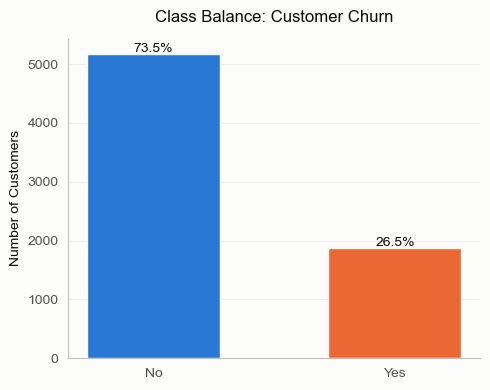

In [32]:
# Step 8: Visualize class imbalance in the target variable (Churn)
counts = df["Churn"].value_counts().reindex(["No", "Yes"])
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index, counts.values, color=[BLUE, ORANGE], width=0.55)
for bar, pct_val in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f"{pct_val:.1f}%", ha="center", fontsize=10, color="#0b0b0b")

ax.set_title("Class Balance: Customer Churn", fontsize=12, pad=12)
ax.set_ylabel("Number of Customers")
ax.set_xlabel("")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

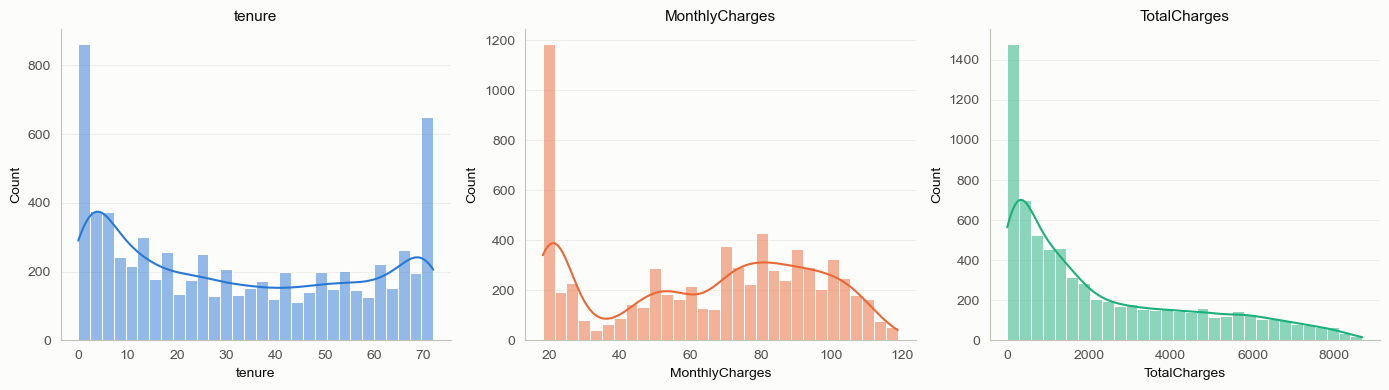

In [33]:
# Step 9: Visualize the distribution shape of each numeric feature
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
dist_colors = [BLUE, ORANGE, AQUA]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, numeric_cols, dist_colors):
    sns.histplot(df[col], bins=30, kde=True, color=color, ax=ax, edgecolor="white")
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Count")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

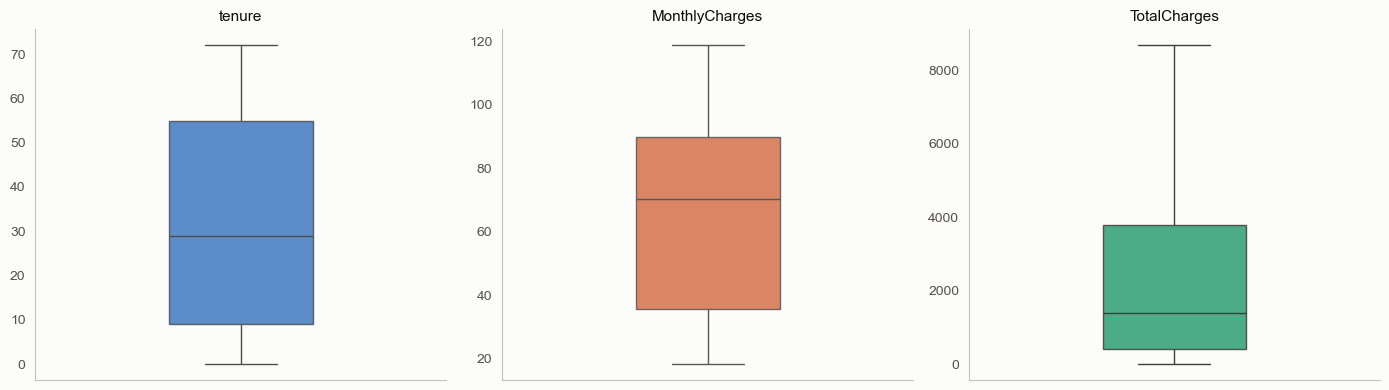

In [34]:
# Step 10: Check numeric features for outliers via boxplots before scaling
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, numeric_cols, dist_colors):
    sns.boxplot(y=df[col], ax=ax, color=color, width=0.35,
                boxprops=dict(alpha=0.85),
                flierprops=dict(markeredgecolor=color, markersize=4))
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [35]:
# Step 11: Collapse "No internet/phone service" into "No" - redundant with InternetService/PhoneService
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
df[service_cols] = df[service_cols].replace("No internet service", "No")
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

In [36]:
# Step 12: Encode the target and all binary Yes/No categorical columns to 0/1
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df["gender"] = df["gender"].map({"Female": 0, "Male": 1})

binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling",
               "MultipleLines"] + service_cols
for col in binary_cols:
    df[col] = df[col].map({"No": 0, "Yes": 1})

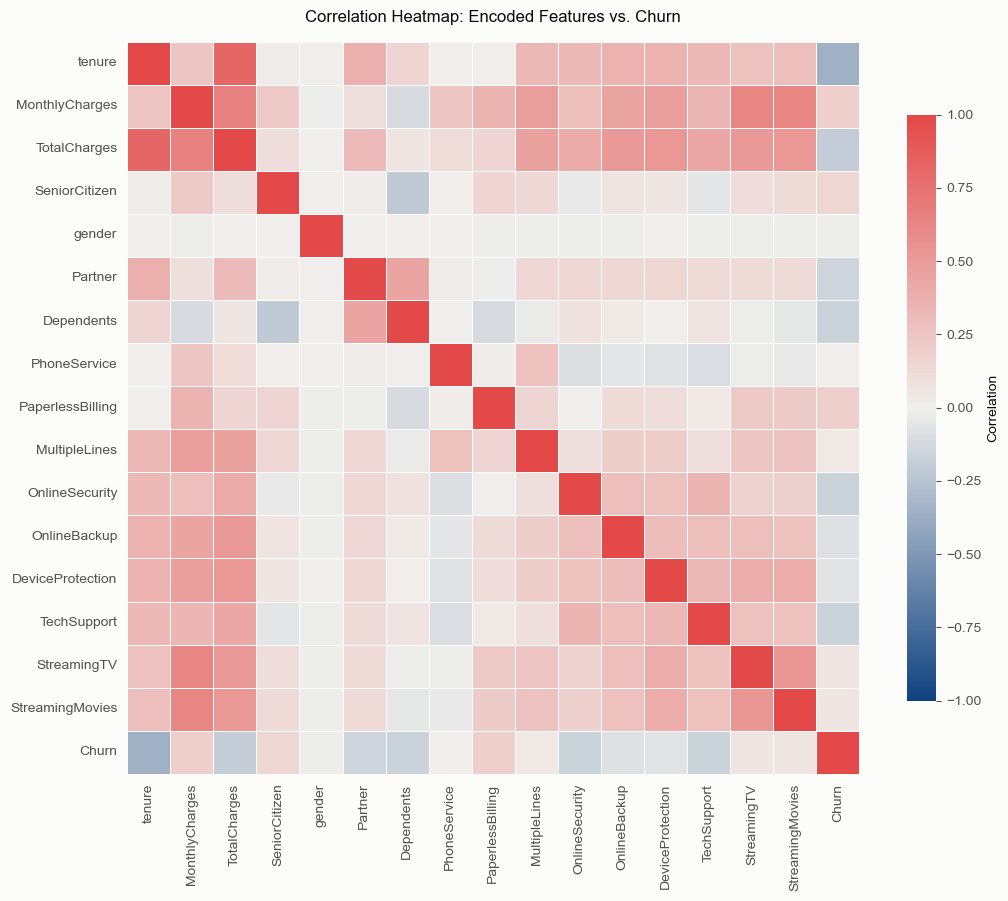

In [37]:
# Step 13: Correlation heatmap of numeric/binary features against Churn
heatmap_cols = numeric_cols + ["SeniorCitizen", "gender"] + binary_cols + ["Churn"]
corr = df[heatmap_cols].corr()

diverging_cmap = mcolors.LinearSegmentedColormap.from_list(
    "diverging_blue_red", ["#104281", "#f0efec", "#e34948"]
)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap=diverging_cmap, vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, linecolor="#fcfcfb",
            cbar_kws={"shrink": 0.8, "label": "Correlation"}, ax=ax)
ax.set_title("Correlation Heatmap: Encoded Features vs. Churn", fontsize=12, pad=14)
plt.tight_layout()
plt.show()

In [38]:
# Step 14: One-hot encode the remaining multi-category nominal columns
nominal_cols = ["InternetService", "Contract", "PaymentMethod"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [39]:
# Step 15: Separate features (X) and target (y)
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [40]:
# Step 16: Stratified 70/15/15 train/validation/test split to preserve class balance in all three sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}, Val churn rate: {y_val.mean():.3f}, Test churn rate: {y_test.mean():.3f}")

Train shape: (4930, 23), Val shape: (1056, 23), Test shape: (1057, 23)
Train churn rate: 0.265, Val churn rate: 0.265, Test churn rate: 0.266


In [41]:
# Step 17: Standardize numeric features - fit scaler on train only, apply to train/val/test
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [42]:
# Step 18: Save the cleaned, encoded, and scaled train/validation/test sets to CSV
train_out = X_train.copy()
train_out["Churn"] = y_train
val_out = X_val.copy()
val_out["Churn"] = y_val
test_out = X_test.copy()
test_out["Churn"] = y_test

train_out.to_csv("dataset/processed/train_clean.csv", index=False)
val_out.to_csv("dataset/processed/val_clean.csv", index=False)
test_out.to_csv("dataset/processed/test_clean.csv", index=False)
print("Saved train_clean.csv, val_clean.csv, and test_clean.csv")
# S3 upload intentionally left out here - handled separately by the user

Saved train_clean.csv, val_clean.csv, and test_clean.csv
